Training classifier for evaluation...
Classifier Epoch 1/5, Accuracy: 79.91%
Classifier Epoch 2/5, Accuracy: 84.95%
Classifier Epoch 3/5, Accuracy: 86.23%
Classifier Epoch 4/5, Accuracy: 86.93%
Classifier Epoch 5/5, Accuracy: 87.28%
Epoch [1/50] | D loss: 0.2018 | G loss: 3.4589
Epoch [2/50] | D loss: 0.2413 | G loss: 3.7425
Epoch [3/50] | D loss: 0.2402 | G loss: 3.5003
Epoch [4/50] | D loss: 0.2295 | G loss: 3.7083
Epoch [5/50] | D loss: 0.3365 | G loss: 2.8279
Epoch [6/50] | D loss: 0.4154 | G loss: 2.1815
Epoch [7/50] | D loss: 0.4115 | G loss: 2.1859
Epoch [8/50] | D loss: 0.4291 | G loss: 2.1195
Epoch [9/50] | D loss: 0.4247 | G loss: 2.1209
Epoch [10/50] | D loss: 0.4570 | G loss: 1.9688

Evaluating GAN Performance...
Inception Score: 5.7039 ± 0.2536
Conditional Accuracy: 76.60%
Mode Coverage: 100.00%
FID Score: 49.1298
Discriminator Confidence on Generated: 0.1175

Epoch [11/50] | D loss: 0.4719 | G loss: 1.7788
Epoch [12/50] | D loss: 0.4903 | G loss: 1.6949
Epoch [13/50] | D 

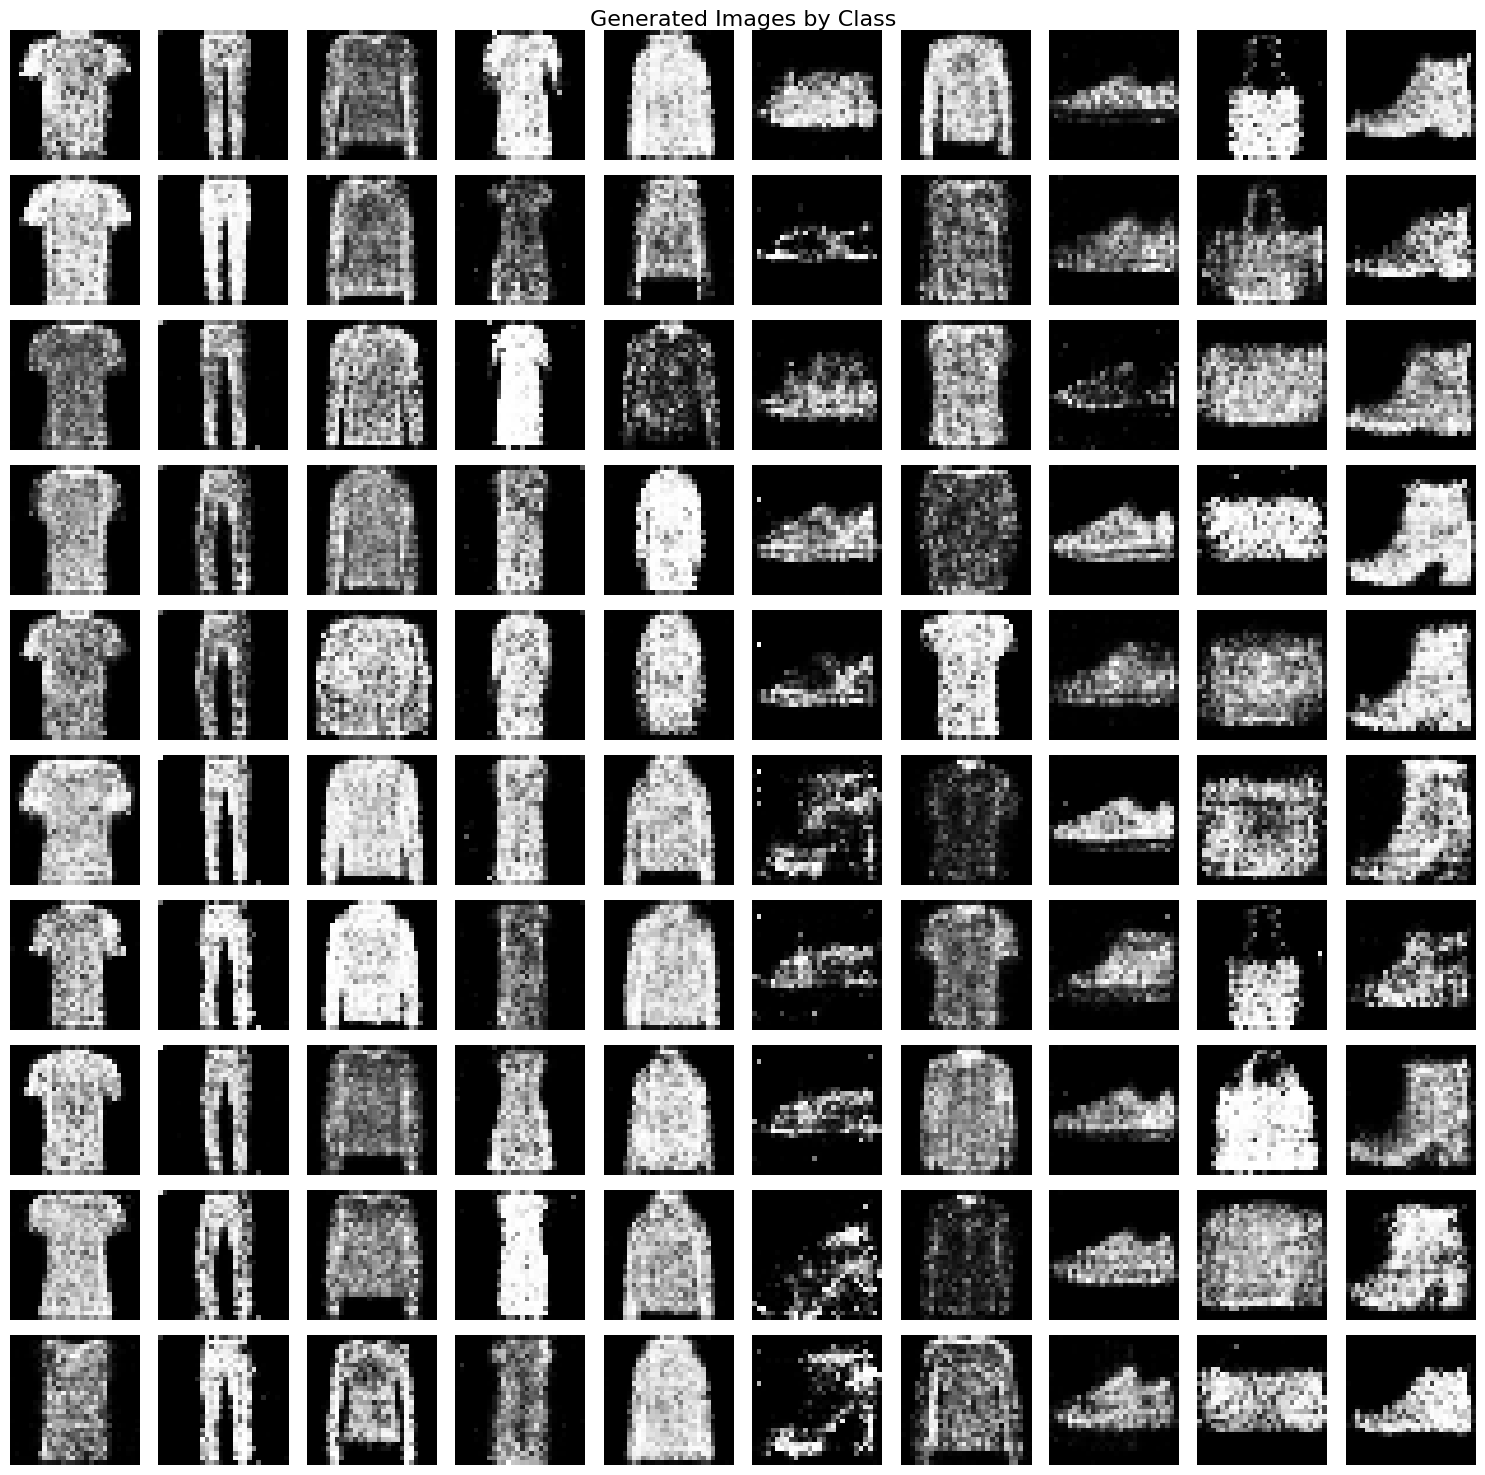

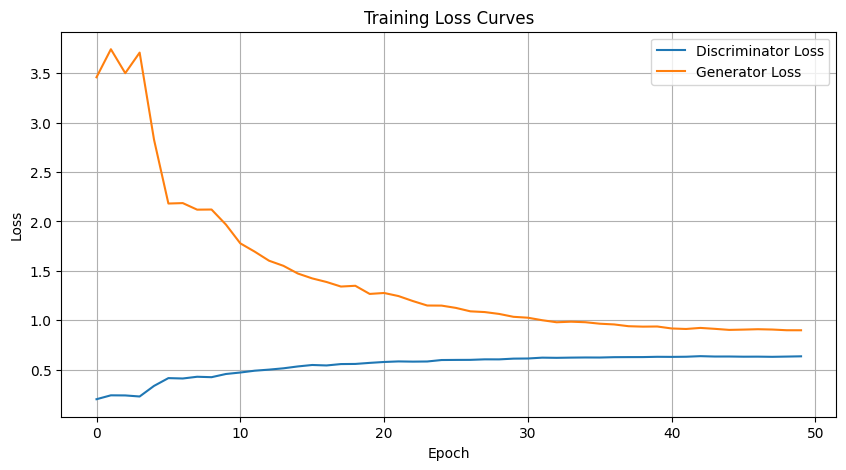


Training completed!


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
from sklearn.metrics import accuracy_score

# -----------------------------
# 1. 超参数
# -----------------------------
batch_size = 128
z_dim = 100
num_classes = 10
lr = 0.0002
epochs = 50  # 增加训练轮数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 2. 数据加载 (Fashion-MNIST)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 加载测试集用于评估
test_dataset = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -----------------------------
# 3. 模型定义
# -----------------------------
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, img_shape),
            nn.Tanh()
        )
    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        img = self.model(x)
        return img.view(img.size(0), 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(img_shape + num_classes, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, img, labels):
        c = self.label_emb(labels)
        x = torch.cat([img.view(img.size(0), -1), c], dim=1)
        return self.model(x)

# -----------------------------
# 4. 评估分类器（用于计算Inception Score和分类准确率）
# -----------------------------
class Classifier(nn.Module):
    """简单的分类器用于评估生成图像"""
    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

def train_classifier():
    """训练一个分类器用于评估"""
    print("Training classifier for evaluation...")
    classifier = Classifier(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=0.001)
    
    classifier.train()
    for epoch in range(5):
        correct = 0
        total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = classifier(imgs)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        acc = 100 * correct / total
        print(f"Classifier Epoch {epoch+1}/5, Accuracy: {acc:.2f}%")
    
    return classifier

# -----------------------------
# 5. 质量评价指标
# -----------------------------
def calculate_inception_score(gen_imgs, classifier, n_split=10, eps=1e-16):
    """
    计算Inception Score (IS)
    IS越高表示生成图像质量越好且多样性越高
    """
    classifier.eval()
    with torch.no_grad():
        preds = torch.softmax(classifier(gen_imgs), dim=1).cpu().numpy()
    
    # 分割成多个部分计算
    split_scores = []
    n_part = preds.shape[0] // n_split
    
    for i in range(n_split):
        part = preds[i * n_part:(i + 1) * n_part]
        py = np.mean(part, axis=0)  # 边际分布
        scores = []
        for j in range(part.shape[0]):
            pyx = part[j]
            scores.append(np.sum(pyx * np.log(pyx / (py + eps) + eps)))
        split_scores.append(np.exp(np.mean(scores)))
    
    return np.mean(split_scores), np.std(split_scores)

def calculate_fid(real_features, fake_features):
    """
    计算Fréchet Inception Distance (FID)
    FID越低表示生成图像与真实图像分布越接近
    """
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def extract_features(imgs, model):
    """提取特征用于FID计算"""
    model.eval()
    with torch.no_grad():
        # 使用分类器的倒数第二层作为特征
        x = imgs.view(imgs.size(0), -1)
        for layer in list(model.model.children())[:-1]:
            x = layer(x)
        return x.cpu().numpy()

def calculate_mode_score(gen_labels, num_classes):
    """
    计算模式覆盖率
    衡量生成器是否能生成所有类别的样本
    """
    unique_labels = len(np.unique(gen_labels))
    mode_coverage = unique_labels / num_classes
    return mode_coverage

def calculate_conditional_accuracy(G, classifier, num_samples=1000):
    """
    计算条件准确率
    衡量生成的图像是否符合给定的类别标签
    """
    G.eval()
    classifier.eval()
    
    all_true_labels = []
    all_pred_labels = []
    
    with torch.no_grad():
        for _ in range(num_samples // num_classes):
            z = torch.randn(num_classes, z_dim, device=device)
            labels = torch.arange(0, num_classes, device=device)
            gen_imgs = G(z, labels)
            
            outputs = classifier(gen_imgs)
            _, predicted = torch.max(outputs.data, 1)
            
            all_true_labels.extend(labels.cpu().numpy())
            all_pred_labels.extend(predicted.cpu().numpy())
    
    accuracy = accuracy_score(all_true_labels, all_pred_labels)
    return accuracy

def evaluate_gan(G, D, classifier, test_loader, num_samples=1000):
    """综合评估GAN性能"""
    print("\n" + "="*50)
    print("Evaluating GAN Performance...")
    print("="*50)
    
    G.eval()
    
    # 1. 生成样本
    with torch.no_grad():
        z = torch.randn(num_samples, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (num_samples,), device=device)
        gen_imgs = G(z, gen_labels)
    
    # 2. Inception Score
    is_mean, is_std = calculate_inception_score(gen_imgs, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 3. 条件准确率
    cond_acc = calculate_conditional_accuracy(G, classifier, num_samples)
    print(f"Conditional Accuracy: {cond_acc*100:.2f}%")
    
    # 4. 模式覆盖率
    mode_cov = calculate_mode_score(gen_labels.cpu().numpy(), num_classes)
    print(f"Mode Coverage: {mode_cov*100:.2f}%")
    
    # 5. FID Score
    # 提取真实图像特征
    real_features_list = []
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        features = extract_features(imgs, classifier)
        real_features_list.append(features)
        if len(real_features_list) * batch_size >= num_samples:
            break
    real_features = np.vstack(real_features_list)[:num_samples]
    
    # 提取生成图像特征
    fake_features = extract_features(gen_imgs, classifier)
    
    fid_score = calculate_fid(real_features, fake_features)
    print(f"FID Score: {fid_score:.4f}")
    
    # 6. 判别器置信度
    with torch.no_grad():
        d_real_conf = D(gen_imgs, gen_labels).mean().item()
    print(f"Discriminator Confidence on Generated: {d_real_conf:.4f}")
    
    print("="*50 + "\n")
    
    return {
        'is_mean': is_mean,
        'is_std': is_std,
        'cond_acc': cond_acc,
        'mode_cov': mode_cov,
        'fid': fid_score,
        'd_conf': d_real_conf
    }

# -----------------------------
# 6. 初始化模型与优化器
# -----------------------------
G = Generator(z_dim, num_classes).to(device)
D = Discriminator(num_classes).to(device)
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# 训练评估分类器
classifier = train_classifier()

# -----------------------------
# 7. 训练循环（带评估）
# -----------------------------
history = {'d_loss': [], 'g_loss': [], 'metrics': []}

for epoch in range(epochs):
    G.train()
    D.train()
    
    epoch_d_loss = 0
    epoch_g_loss = 0
    num_batches = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        batch_size = imgs.size(0)

        # 真/假标签
        real = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        # 训练判别器 D
        z = torch.randn(batch_size, z_dim, device=device)
        fake_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        fake_imgs = G(z, fake_labels)

        real_loss = criterion(D(imgs, labels), real)
        fake_loss = criterion(D(fake_imgs.detach(), fake_labels), fake)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # 训练生成器 G
        z = torch.randn(batch_size, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        gen_imgs = G(z, gen_labels)
        g_loss = criterion(D(gen_imgs, gen_labels), real)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()
        
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches += 1

    avg_d_loss = epoch_d_loss / num_batches
    avg_g_loss = epoch_g_loss / num_batches
    history['d_loss'].append(avg_d_loss)
    history['g_loss'].append(avg_g_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | D loss: {avg_d_loss:.4f} | G loss: {avg_g_loss:.4f}")
    
    # 每10个epoch评估一次
    if (epoch + 1) % 10 == 0:
        metrics = evaluate_gan(G, D, classifier, test_loader)
        history['metrics'].append(metrics)

# -----------------------------
# 8. 最终评估
# -----------------------------
final_metrics = evaluate_gan(G, D, classifier, test_loader)

# -----------------------------
# 9. 可视化结果
# -----------------------------
# 生成每个类别的样本
G.eval()
with torch.no_grad():
    z = torch.randn(num_classes * 10, z_dim, device=device)
    labels = torch.arange(0, num_classes, device=device).repeat(10)
    gen_imgs = G(z, labels).cpu()

# 绘制生成样本网格
fig, axes = plt.subplots(num_classes, 10, figsize=(15, 15))
for i in range(num_classes):
    for j in range(10):
        idx = i * 10 + j
        axes[i, j].imshow(gen_imgs[idx].squeeze() * 0.5 + 0.5, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(f'Class {i}', fontsize=12)

plt.suptitle('Generated Images by Class', fontsize=16)
plt.tight_layout()
plt.show()

# 绘制训练损失曲线
plt.figure(figsize=(10, 5))
plt.plot(history['d_loss'], label='Discriminator Loss')
plt.plot(history['g_loss'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

print("\nTraining completed!")

Training classifier for evaluation...
Classifier Epoch 1/5, Accuracy: 79.92%
Classifier Epoch 2/5, Accuracy: 84.89%
Classifier Epoch 3/5, Accuracy: 86.25%
Classifier Epoch 4/5, Accuracy: 86.89%
Classifier Epoch 5/5, Accuracy: 87.55%
Epoch [1/50] | D loss: 0.1721 | G loss: 3.6751
Epoch [2/50] | D loss: 0.2532 | G loss: 3.5792
Epoch [3/50] | D loss: 0.3174 | G loss: 2.8962
Epoch [4/50] | D loss: 0.3765 | G loss: 2.4036
Epoch [5/50] | D loss: 0.3849 | G loss: 2.3125
Epoch [6/50] | D loss: 0.3939 | G loss: 2.2431
Epoch [7/50] | D loss: 0.4187 | G loss: 2.0571
Epoch [8/50] | D loss: 0.4407 | G loss: 1.9155
Epoch [9/50] | D loss: 0.4537 | G loss: 1.8361
Epoch [10/50] | D loss: 0.4683 | G loss: 1.7366

Evaluating GAN Performance...
Inception Score: 6.1548 ± 0.2591
Conditional Accuracy: 78.70%
Mode Coverage: 100.00%
FID Score: 34.3868
Discriminator Confidence on Generated: 0.2256

Epoch [11/50] | D loss: 0.4750 | G loss: 1.6970
Epoch [12/50] | D loss: 0.4988 | G loss: 1.5922
Epoch [13/50] | D 

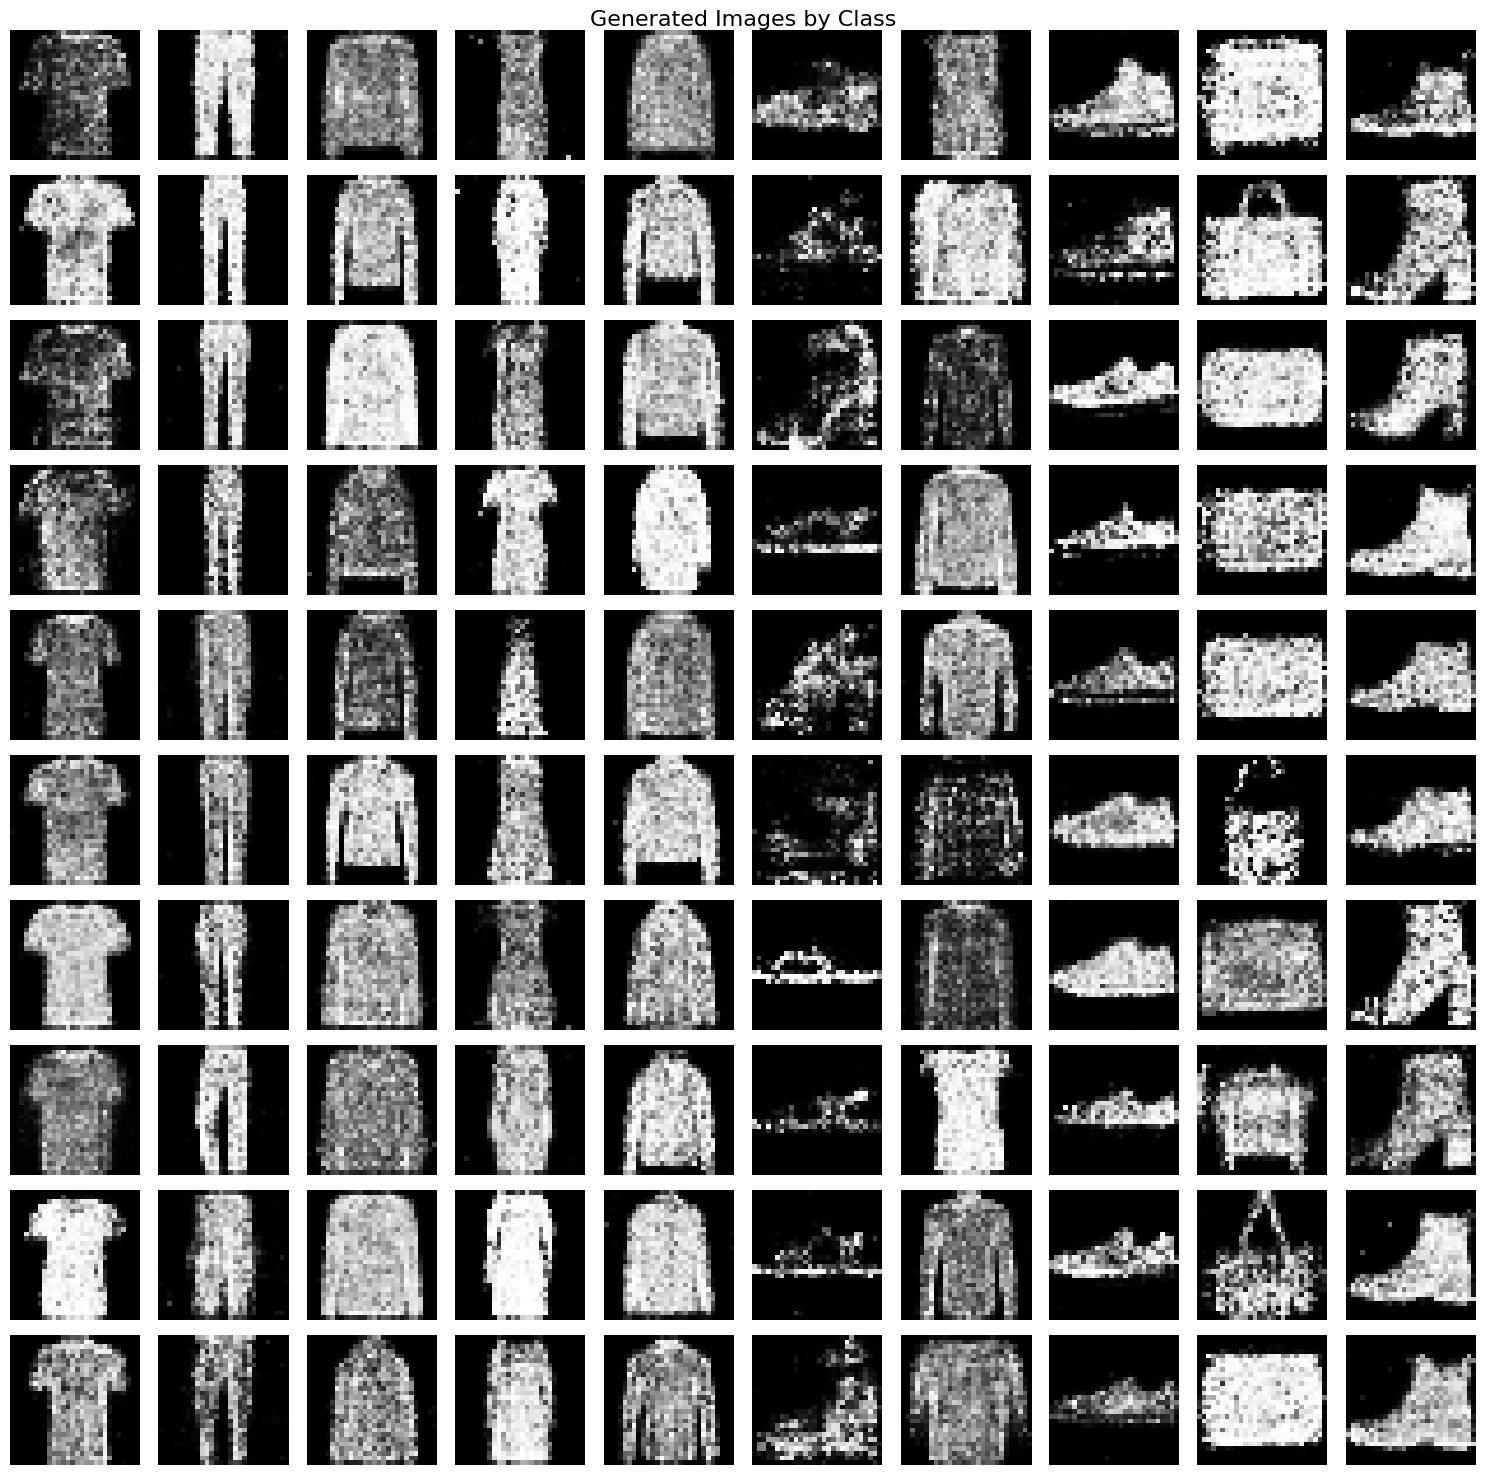

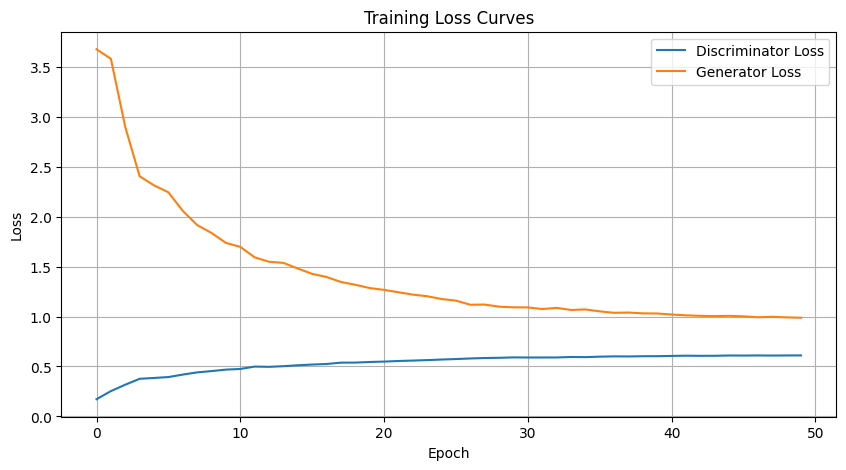


 Training completed!


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
from sklearn.metrics import accuracy_score

# -----------------------------
# 1. 超参数
# -----------------------------
batch_size = 128
z_dim = 100
num_classes = 10
lr = 0.0002
epochs = 50  # 增加训练轮数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 2. 数据加载 (Fashion-MNIST)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 加载测试集用于评估
test_dataset = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -----------------------------
# 3. 模型定义
# -----------------------------
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, img_shape),
            nn.Tanh()
        )
    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        img = self.model(x)
        return img.view(img.size(0), 1, 28, 28)

class Vsig(nn.Module):
    def __init__(self, init_sigma=0.3):  # 建议默认值就写 1.0（浮点数）
        super(Vsig, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = 1 / (1 + torch.exp(-input /sigma_safe ))
        return output

class Discriminator(nn.Module):
    def __init__(self, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(img_shape + num_classes, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )
        self.vsig = Vsig()  # 可学习的sigmoid激活
    
    def forward(self, img, labels):
        c = self.label_emb(labels)
        x = torch.cat([img.view(img.size(0), -1), c], dim=1)
        logits = self.model(x)
        output = self.vsig(logits)  # 应用可学习的sigmoid
        return output

# -----------------------------
# 4. 评估分类器（用于计算Inception Score和分类准确率）
# -----------------------------
class Classifier(nn.Module):
    """简单的分类器用于评估生成图像"""
    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

def train_classifier():
    """训练一个分类器用于评估"""
    print("Training classifier for evaluation...")
    classifier = Classifier(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=0.001)
    
    classifier.train()
    for epoch in range(5):
        correct = 0
        total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = classifier(imgs)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        acc = 100 * correct / total
        print(f"Classifier Epoch {epoch+1}/5, Accuracy: {acc:.2f}%")
    
    return classifier

# -----------------------------
# 5. 质量评价指标
# -----------------------------
def calculate_inception_score(gen_imgs, classifier, n_split=10, eps=1e-16):
    """
    计算Inception Score (IS)
    IS越高表示生成图像质量越好且多样性越高
    """
    classifier.eval()
    with torch.no_grad():
        preds = torch.softmax(classifier(gen_imgs), dim=1).cpu().numpy()
    
    # 分割成多个部分计算
    split_scores = []
    n_part = preds.shape[0] // n_split
    
    for i in range(n_split):
        part = preds[i * n_part:(i + 1) * n_part]
        py = np.mean(part, axis=0)  # 边际分布
        scores = []
        for j in range(part.shape[0]):
            pyx = part[j]
            scores.append(np.sum(pyx * np.log(pyx / (py + eps) + eps)))
        split_scores.append(np.exp(np.mean(scores)))
    
    return np.mean(split_scores), np.std(split_scores)

def calculate_fid(real_features, fake_features):
    """
    计算Fréchet Inception Distance (FID)
    FID越低表示生成图像与真实图像分布越接近
    """
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def extract_features(imgs, model):
    """提取特征用于FID计算"""
    model.eval()
    with torch.no_grad():
        # 使用分类器的倒数第二层作为特征
        x = imgs.view(imgs.size(0), -1)
        for layer in list(model.model.children())[:-1]:
            x = layer(x)
        return x.cpu().numpy()

def calculate_mode_score(gen_labels, num_classes):
    """
    计算模式覆盖率
    衡量生成器是否能生成所有类别的样本
    """
    unique_labels = len(np.unique(gen_labels))
    mode_coverage = unique_labels / num_classes
    return mode_coverage

def calculate_conditional_accuracy(G, classifier, num_samples=1000):
    """
    计算条件准确率
    衡量生成的图像是否符合给定的类别标签
    """
    G.eval()
    classifier.eval()
    
    all_true_labels = []
    all_pred_labels = []
    
    with torch.no_grad():
        for _ in range(num_samples // num_classes):
            z = torch.randn(num_classes, z_dim, device=device)
            labels = torch.arange(0, num_classes, device=device)
            gen_imgs = G(z, labels)
            
            outputs = classifier(gen_imgs)
            _, predicted = torch.max(outputs.data, 1)
            
            all_true_labels.extend(labels.cpu().numpy())
            all_pred_labels.extend(predicted.cpu().numpy())
    
    accuracy = accuracy_score(all_true_labels, all_pred_labels)
    return accuracy

def evaluate_gan(G, D, classifier, test_loader, num_samples=1000):
    """综合评估GAN性能"""
    print("\n" + "="*50)
    print("Evaluating GAN Performance...")
    print("="*50)
    
    G.eval()
    
    # 1. 生成样本
    with torch.no_grad():
        z = torch.randn(num_samples, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (num_samples,), device=device)
        gen_imgs = G(z, gen_labels)
    
    # 2. Inception Score
    is_mean, is_std = calculate_inception_score(gen_imgs, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 3. 条件准确率
    cond_acc = calculate_conditional_accuracy(G, classifier, num_samples)
    print(f"Conditional Accuracy: {cond_acc*100:.2f}%")
    
    # 4. 模式覆盖率
    mode_cov = calculate_mode_score(gen_labels.cpu().numpy(), num_classes)
    print(f"Mode Coverage: {mode_cov*100:.2f}%")
    
    # 5. FID Score
    # 提取真实图像特征
    real_features_list = []
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        features = extract_features(imgs, classifier)
        real_features_list.append(features)
        if len(real_features_list) * batch_size >= num_samples:
            break
    real_features = np.vstack(real_features_list)[:num_samples]
    
    # 提取生成图像特征
    fake_features = extract_features(gen_imgs, classifier)
    
    fid_score = calculate_fid(real_features, fake_features)
    print(f"FID Score: {fid_score:.4f}")
    
    # 6. 判别器置信度
    with torch.no_grad():
        d_real_conf = D(gen_imgs, gen_labels).mean().item()
    print(f"Discriminator Confidence on Generated: {d_real_conf:.4f}")
    
    print("="*50 + "\n")
    
    return {
        'is_mean': is_mean,
        'is_std': is_std,
        'cond_acc': cond_acc,
        'mode_cov': mode_cov,
        'fid': fid_score,
        'd_conf': d_real_conf
    }

# -----------------------------
# 6. 初始化模型与优化器
# -----------------------------
G = Generator(z_dim, num_classes).to(device)
D = Discriminator(num_classes).to(device)
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# 训练评估分类器
classifier = train_classifier()

# -----------------------------
# 7. 训练循环（带评估）
# -----------------------------
history = {'d_loss': [], 'g_loss': [], 'metrics': []}

for epoch in range(epochs):
    G.train()
    D.train()
    
    epoch_d_loss = 0
    epoch_g_loss = 0
    num_batches = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        batch_size = imgs.size(0)

        # 真/假标签
        real = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        # 训练判别器 D
        z = torch.randn(batch_size, z_dim, device=device)
        fake_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        fake_imgs = G(z, fake_labels)

        real_loss = criterion(D(imgs, labels), real)
        fake_loss = criterion(D(fake_imgs.detach(), fake_labels), fake)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # 训练生成器 G
        z = torch.randn(batch_size, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        gen_imgs = G(z, gen_labels)
        g_loss = criterion(D(gen_imgs, gen_labels), real)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()
        
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches += 1

    avg_d_loss = epoch_d_loss / num_batches
    avg_g_loss = epoch_g_loss / num_batches
    history['d_loss'].append(avg_d_loss)
    history['g_loss'].append(avg_g_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | D loss: {avg_d_loss:.4f} | G loss: {avg_g_loss:.4f}")
    
    # 每10个epoch评估一次
    if (epoch + 1) % 10 == 0:
        metrics = evaluate_gan(G, D, classifier, test_loader)
        history['metrics'].append(metrics)

# -----------------------------
# 8. 最终评估
# -----------------------------
final_metrics = evaluate_gan(G, D, classifier, test_loader)

# -----------------------------
# 9. 可视化结果
# -----------------------------
# 生成每个类别的样本
G.eval()
with torch.no_grad():
    z = torch.randn(num_classes * 10, z_dim, device=device)
    labels = torch.arange(0, num_classes, device=device).repeat(10)
    gen_imgs = G(z, labels).cpu()

# 绘制生成样本网格
fig, axes = plt.subplots(num_classes, 10, figsize=(15, 15))
for i in range(num_classes):
    for j in range(10):
        idx = i * 10 + j
        axes[i, j].imshow(gen_imgs[idx].squeeze() * 0.5 + 0.5, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(f'Class {i}', fontsize=12)

plt.suptitle('Generated Images by Class', fontsize=16)
plt.tight_layout()
plt.show()

# 绘制训练损失曲线
plt.figure(figsize=(10, 5))
plt.plot(history['d_loss'], label='Discriminator Loss')
plt.plot(history['g_loss'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

print("\n Training completed!")

In [ ]:
import os
import torch
import json
import numpy as np
from datetime import datetime

# -----------------------------
# 辅助函数：类型转换
# -----------------------------
def convert_to_serializable(obj):
    """
    递归转换NumPy类型为Python原生类型，使其可以JSON序列化
    """
    if isinstance(obj, dict):
        return {key: convert_to_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, torch.Tensor):
        return obj.cpu().numpy().tolist()
    else:
        return obj

# -----------------------------
# 1. 创建保存目录
# -----------------------------
def create_save_directory(base_dir='./saved_models'):
    """创建保存目录"""
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    save_dir = os.path.join(base_dir, f'cgan_{timestamp}')
    os.makedirs(save_dir, exist_ok=True)
    return save_dir

# -----------------------------
# 2. 保存完整模型（推荐）
# -----------------------------
def save_complete_model(G, D, classifier, optimizer_G, optimizer_D, 
                       history, final_metrics, save_dir, z_dim=100, 
                       num_classes=10, epochs=50, batch_size=64, lr=0.0002):
    """
    保存所有模型参数、优化器状态和训练历史
    """
    checkpoint = {
        # 模型状态
        'generator_state_dict': G.state_dict(),
        'discriminator_state_dict': D.state_dict(),
        'classifier_state_dict': classifier.state_dict(),
        
        # 优化器状态
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_state_dict': optimizer_D.state_dict(),
        
        # 训练历史和指标（已转换类型）
        'history': convert_to_serializable(history),
        'final_metrics': convert_to_serializable(final_metrics),
        
        # 超参数
        'hyperparameters': {
            'z_dim': z_dim,
            'num_classes': num_classes,
            'epochs': epochs,
            'batch_size': batch_size,
            'lr': lr
        },
        
        # Vsig参数（重要！）
        'vsig_sigma': float(D.vsig.sigma.item())
    }
    
    # 保存完整checkpoint
    checkpoint_path = os.path.join(save_dir, 'checkpoint_complete.pth')
    torch.save(checkpoint, checkpoint_path)
    print(f"✅ Complete checkpoint saved to: {checkpoint_path}")
    
    # 单独保存各个模型（便于只加载某一个）
    torch.save(G.state_dict(), os.path.join(save_dir, 'generator.pth'))
    torch.save(D.state_dict(), os.path.join(save_dir, 'discriminator.pth'))
    torch.save(classifier.state_dict(), os.path.join(save_dir, 'classifier.pth'))
    print(f"✅ Individual models saved to: {save_dir}")
    
    # 保存评估指标为JSON（已转换类型）
    metrics_path = os.path.join(save_dir, 'metrics.json')
    metrics_serializable = convert_to_serializable(final_metrics)
    with open(metrics_path, 'w') as f:
        json.dump(metrics_serializable, f, indent=4)
    print(f"✅ Metrics saved to: {metrics_path}")
    
    # 保存训练历史（已转换类型）
    history_path = os.path.join(save_dir, 'training_history.json')
    history_serializable = convert_to_serializable(history)
    with open(history_path, 'w') as f:
        json.dump(history_serializable, f, indent=4)
    print(f"✅ Training history saved to: {history_path}")
    
    return checkpoint_path

# -----------------------------
# 3. 加载模型
# -----------------------------
def load_complete_model(checkpoint_path, device='cuda'):
    """
    加载完整的模型和训练状态
    需要提前定义好 Generator, Discriminator, Classifier 类
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # 重建模型
    hp = checkpoint['hyperparameters']
    
    # 注意：这里需要您已经定义了这些类
    from torch import optim
    G = Generator(hp['z_dim'], hp['num_classes']).to(device)
    D = Discriminator(hp['num_classes']).to(device)
    classifier = Classifier(hp['num_classes']).to(device)
    
    # 加载模型参数
    G.load_state_dict(checkpoint['generator_state_dict'])
    D.load_state_dict(checkpoint['discriminator_state_dict'])
    classifier.load_state_dict(checkpoint['classifier_state_dict'])
    
    # 加载优化器（如果需要继续训练）
    optimizer_G = optim.Adam(G.parameters(), lr=hp['lr'], betas=(0.5, 0.999))
    optimizer_D = optim.Adam(D.parameters(), lr=hp['lr'], betas=(0.5, 0.999))
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
    
    print(f"✅ Model loaded from: {checkpoint_path}")
    print(f"📊 Vsig sigma: {checkpoint['vsig_sigma']:.4f}")
    print(f"📊 Final FID: {checkpoint['final_metrics']['fid']:.4f}")
    
    return G, D, classifier, optimizer_G, optimizer_D, checkpoint

# -----------------------------
# 4. 只加载生成器（用于生成图像）
# -----------------------------
def load_generator_only(model_dir, z_dim=100, num_classes=10, device='cuda'):
    """
    只加载生成器用于生成图像
    """
    G = Generator(z_dim, num_classes).to(device)
    generator_path = os.path.join(model_dir, 'generator.pth')
    G.load_state_dict(torch.load(generator_path, map_location=device))
    G.eval()
    print(f"✅ Generator loaded from: {generator_path}")
    return G

# -----------------------------
# 5. 保存最佳模型（基于FID）
# -----------------------------
class BestModelSaver:
    """自动保存最佳模型"""
    def __init__(self, save_dir, metric='fid', mode='min'):
        self.save_dir = save_dir
        self.metric = metric
        self.mode = mode
        self.best_value = float('inf') if mode == 'min' else float('-inf')
        self.best_epoch = 0
    
    def update(self, epoch, metrics, G, D, classifier, optimizer_G, optimizer_D, history):
        """检查并更新最佳模型"""
        current_value = metrics[self.metric]
        
        is_better = (current_value < self.best_value if self.mode == 'min' 
                    else current_value > self.best_value)
        
        if is_better:
            self.best_value = current_value
            self.best_epoch = epoch
            
            # 保存最佳模型
            best_path = os.path.join(self.save_dir, 'best_model.pth')
            checkpoint = {
                'epoch': epoch,
                'generator_state_dict': G.state_dict(),
                'discriminator_state_dict': D.state_dict(),
                'classifier_state_dict': classifier.state_dict(),
                'optimizer_G_state_dict': optimizer_G.state_dict(),
                'optimizer_D_state_dict': optimizer_D.state_dict(),
                'metrics': convert_to_serializable(metrics),
                'history': convert_to_serializable(history),
                'best_metric': {self.metric: float(self.best_value)}
            }
            torch.save(checkpoint, best_path)
            print(f"🏆 New best model saved! {self.metric}={self.best_value:.4f} at epoch {epoch}")

# -----------------------------
# 使用示例
# -----------------------------


# ========== 在训练代码最后添加 ==========

# 创建保存目录
save_dir = create_save_directory('D:/PRE2023 2025/CGAN')

# 保存完整模型
checkpoint_path = save_complete_model(
    G, D, classifier, 
    optimizer_G, optimizer_D,
    history, final_metrics,
    save_dir,
    z_dim=100,  # 根据您的实际值修改
    num_classes=10,
    epochs=50,
    batch_size=64,
    lr=0.0002
)

print(f"\n{'='*50}")
print(f"✅ All models saved to: {save_dir}")
print(f"{'='*50}\n")


# ========== 加载模型示例 ==========

# 1. 加载完整模型继续训练
G, D, classifier, opt_G, opt_D, checkpoint = load_complete_model(
    'D:/PRE2023 2025/CGAN/cgan_20251006_150016/checkpoint_complete.pth'
)

# 2. 只加载生成器生成图像
G = load_generator_only('D:/PRE2023 2025/CGAN/cgan_20251006_150016')
with torch.no_grad():
    z = torch.randn(10, 100, device='cuda')
    labels = torch.arange(0, 10, device='cuda')
    gen_imgs = G(z, labels)

# 3. 在训练循环中使用最佳模型保存器
best_saver = BestModelSaver(save_dir, metric='fid', mode='min')

for epoch in range(epochs):
    # ... 训练代码 ...
    
    if (epoch + 1) % 10 == 0:
        metrics = evaluate_gan(G, D, classifier, test_loader)
        best_saver.update(epoch+1, metrics, G, D, classifier, 
                         optimizer_G, optimizer_D, history)

✅ Complete checkpoint saved to: D:/PRE2023 2025/CGAN\cgan_20251006_150252\checkpoint_complete.pth
✅ Individual models saved to: D:/PRE2023 2025/CGAN\cgan_20251006_150252
✅ Metrics saved to: D:/PRE2023 2025/CGAN\cgan_20251006_150252\metrics.json
✅ Training history saved to: D:/PRE2023 2025/CGAN\cgan_20251006_150252\training_history.json

✅ All models saved to: D:/PRE2023 2025/CGAN\cgan_20251006_150252

✅ Model loaded from: D:/PRE2023 2025/CGAN/cgan_20251006_150016/checkpoint_complete.pth
📊 Vsig sigma: 0.1498
📊 Final FID: 8.7273
✅ Generator loaded from: D:/PRE2023 2025/CGAN/cgan_20251006_150016\generator.pth

Evaluating GAN Performance...
Inception Score: 6.8690 ± 0.2268
Conditional Accuracy: 87.30%
Mode Coverage: 100.00%
FID Score: 9.6793
Discriminator Confidence on Generated: 0.3520

🏆 New best model saved! fid=9.6793 at epoch 10

Evaluating GAN Performance...
Inception Score: 6.6950 ± 0.2679
Conditional Accuracy: 88.80%
Mode Coverage: 100.00%
FID Score: 9.2407
Discriminator Confidence

In [1]:
#高斯的最后一层激活函数

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
from sklearn.metrics import accuracy_score

# -----------------------------
# 1. 超参数
# -----------------------------
batch_size = 128
z_dim = 100
num_classes = 10
lr = 0.0002
epochs = 50  # 增加训练轮数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 2. 数据加载 (Fashion-MNIST)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 加载测试集用于评估
test_dataset = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -----------------------------
# 3. 模型定义
# -----------------------------
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, img_shape),
            nn.Tanh()
        )
    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        img = self.model(x)
        return img.view(img.size(0), 1, 28, 28)

class Vsig(nn.Module):
    def __init__(self, init_sigma=2.0):  # 建议默认值就写 1.0（浮点数）
        super(Vsig, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = (1 + torch.erf(input / (torch.sqrt(torch.tensor(2.0)) * sigma_safe))) / 2
        return output

class Discriminator(nn.Module):
    def __init__(self, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(img_shape + num_classes, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )
        self.vsig = Vsig()  # 可学习的sigmoid激活
    
    def forward(self, img, labels):
        c = self.label_emb(labels)
        x = torch.cat([img.view(img.size(0), -1), c], dim=1)
        logits = self.model(x)
        output = self.vsig(logits)  # 应用可学习的sigmoid
        return output

# -----------------------------
# 4. 评估分类器（用于计算Inception Score和分类准确率）
# -----------------------------
class Classifier(nn.Module):
    """简单的分类器用于评估生成图像"""
    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

def train_classifier():
    """训练一个分类器用于评估"""
    print("Training classifier for evaluation...")
    classifier = Classifier(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=0.001)
    
    classifier.train()
    for epoch in range(5):
        correct = 0
        total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = classifier(imgs)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        acc = 100 * correct / total
        print(f"Classifier Epoch {epoch+1}/5, Accuracy: {acc:.2f}%")
    
    return classifier

# -----------------------------
# 5. 质量评价指标
# -----------------------------
def calculate_inception_score(gen_imgs, classifier, n_split=10, eps=1e-16):
    """
    计算Inception Score (IS)
    IS越高表示生成图像质量越好且多样性越高
    """
    classifier.eval()
    with torch.no_grad():
        preds = torch.softmax(classifier(gen_imgs), dim=1).cpu().numpy()
    
    # 分割成多个部分计算
    split_scores = []
    n_part = preds.shape[0] // n_split
    
    for i in range(n_split):
        part = preds[i * n_part:(i + 1) * n_part]
        py = np.mean(part, axis=0)  # 边际分布
        scores = []
        for j in range(part.shape[0]):
            pyx = part[j]
            scores.append(np.sum(pyx * np.log(pyx / (py + eps) + eps)))
        split_scores.append(np.exp(np.mean(scores)))
    
    return np.mean(split_scores), np.std(split_scores)

def calculate_fid(real_features, fake_features):
    """
    计算Fréchet Inception Distance (FID)
    FID越低表示生成图像与真实图像分布越接近
    """
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def extract_features(imgs, model):
    """提取特征用于FID计算"""
    model.eval()
    with torch.no_grad():
        # 使用分类器的倒数第二层作为特征
        x = imgs.view(imgs.size(0), -1)
        for layer in list(model.model.children())[:-1]:
            x = layer(x)
        return x.cpu().numpy()

def calculate_mode_score(gen_labels, num_classes):
    """
    计算模式覆盖率
    衡量生成器是否能生成所有类别的样本
    """
    unique_labels = len(np.unique(gen_labels))
    mode_coverage = unique_labels / num_classes
    return mode_coverage

def calculate_conditional_accuracy(G, classifier, num_samples=1000):
    """
    计算条件准确率
    衡量生成的图像是否符合给定的类别标签
    """
    G.eval()
    classifier.eval()
    
    all_true_labels = []
    all_pred_labels = []
    
    with torch.no_grad():
        for _ in range(num_samples // num_classes):
            z = torch.randn(num_classes, z_dim, device=device)
            labels = torch.arange(0, num_classes, device=device)
            gen_imgs = G(z, labels)
            
            outputs = classifier(gen_imgs)
            _, predicted = torch.max(outputs.data, 1)
            
            all_true_labels.extend(labels.cpu().numpy())
            all_pred_labels.extend(predicted.cpu().numpy())
    
    accuracy = accuracy_score(all_true_labels, all_pred_labels)
    return accuracy

def evaluate_gan(G, D, classifier, test_loader, num_samples=1000):
    """综合评估GAN性能"""
    print("\n" + "="*50)
    print("Evaluating GAN Performance...")
    print("="*50)
    
    G.eval()
    
    # 1. 生成样本
    with torch.no_grad():
        z = torch.randn(num_samples, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (num_samples,), device=device)
        gen_imgs = G(z, gen_labels)
    
    # 2. Inception Score
    is_mean, is_std = calculate_inception_score(gen_imgs, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 3. 条件准确率
    cond_acc = calculate_conditional_accuracy(G, classifier, num_samples)
    print(f"Conditional Accuracy: {cond_acc*100:.2f}%")
    
    # 4. 模式覆盖率
    mode_cov = calculate_mode_score(gen_labels.cpu().numpy(), num_classes)
    print(f"Mode Coverage: {mode_cov*100:.2f}%")
    
    # 5. FID Score
    # 提取真实图像特征
    real_features_list = []
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        features = extract_features(imgs, classifier)
        real_features_list.append(features)
        if len(real_features_list) * batch_size >= num_samples:
            break
    real_features = np.vstack(real_features_list)[:num_samples]
    
    # 提取生成图像特征
    fake_features = extract_features(gen_imgs, classifier)
    
    fid_score = calculate_fid(real_features, fake_features)
    print(f"FID Score: {fid_score:.4f}")
    
    # 6. 判别器置信度
    with torch.no_grad():
        d_real_conf = D(gen_imgs, gen_labels).mean().item()
    print(f"Discriminator Confidence on Generated: {d_real_conf:.4f}")
    
    print("="*50 + "\n")
    
    return {
        'is_mean': is_mean,
        'is_std': is_std,
        'cond_acc': cond_acc,
        'mode_cov': mode_cov,
        'fid': fid_score,
        'd_conf': d_real_conf
    }

# -----------------------------
# 6. 初始化模型与优化器
# -----------------------------
G = Generator(z_dim, num_classes).to(device)
D = Discriminator(num_classes).to(device)
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# 训练评估分类器
classifier = train_classifier()

# -----------------------------
# 7. 训练循环（带评估）
# -----------------------------
history = {'d_loss': [], 'g_loss': [], 'metrics': []}

for epoch in range(epochs):
    G.train()
    D.train()
    
    epoch_d_loss = 0
    epoch_g_loss = 0
    num_batches = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        batch_size = imgs.size(0)

        # 真/假标签
        real = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        # 训练判别器 D
        z = torch.randn(batch_size, z_dim, device=device)
        fake_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        fake_imgs = G(z, fake_labels)

        real_loss = criterion(D(imgs, labels), real)
        fake_loss = criterion(D(fake_imgs.detach(), fake_labels), fake)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # 训练生成器 G
        z = torch.randn(batch_size, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        gen_imgs = G(z, gen_labels)
        g_loss = criterion(D(gen_imgs, gen_labels), real)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()
        
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches += 1

    avg_d_loss = epoch_d_loss / num_batches
    avg_g_loss = epoch_g_loss / num_batches
    history['d_loss'].append(avg_d_loss)
    history['g_loss'].append(avg_g_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | D loss: {avg_d_loss:.4f} | G loss: {avg_g_loss:.4f}")
    
    # 每10个epoch评估一次
    if (epoch + 1) % 10 == 0:
        metrics = evaluate_gan(G, D, classifier, test_loader)
        history['metrics'].append(metrics)

# -----------------------------
# 8. 最终评估
# -----------------------------
final_metrics = evaluate_gan(G, D, classifier, test_loader)

# -----------------------------
# 9. 可视化结果
# -----------------------------
# 生成每个类别的样本
G.eval()
with torch.no_grad():
    z = torch.randn(num_classes * 10, z_dim, device=device)
    labels = torch.arange(0, num_classes, device=device).repeat(10)
    gen_imgs = G(z, labels).cpu()

# 绘制生成样本网格
fig, axes = plt.subplots(num_classes, 10, figsize=(15, 15))
for i in range(num_classes):
    for j in range(10):
        idx = i * 10 + j
        axes[i, j].imshow(gen_imgs[idx].squeeze() * 0.5 + 0.5, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(f'Class {i}', fontsize=12)

plt.suptitle('Generated Images by Class', fontsize=16)
plt.tight_layout()
plt.show()

# 绘制训练损失曲线
plt.figure(figsize=(10, 5))
plt.plot(history['d_loss'], label='Discriminator Loss')
plt.plot(history['g_loss'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

print("\n Training completed!")

Training classifier for evaluation...
Classifier Epoch 1/5, Accuracy: 79.86%
Classifier Epoch 2/5, Accuracy: 84.79%
Classifier Epoch 3/5, Accuracy: 86.27%
Classifier Epoch 4/5, Accuracy: 86.91%
Classifier Epoch 5/5, Accuracy: 87.45%
Epoch [1/50] | D loss: 0.1551 | G loss: 4.7090
Epoch [2/50] | D loss: 0.6158 | G loss: 2.3709
Epoch [3/50] | D loss: 1.3394 | G loss: 0.2112
Epoch [4/50] | D loss: 1.4947 | G loss: 0.1075
Epoch [5/50] | D loss: 0.6941 | G loss: 0.8937
Epoch [6/50] | D loss: 0.5433 | G loss: 0.9656
Epoch [7/50] | D loss: 0.9004 | G loss: 0.4497
Epoch [8/50] | D loss: 0.9243 | G loss: 0.5210
Epoch [9/50] | D loss: 0.3407 | G loss: 1.2737
Epoch [10/50] | D loss: 0.3770 | G loss: 1.1804

Evaluating GAN Performance...
Inception Score: 1.0122 ± 0.0020
Conditional Accuracy: 10.00%
Mode Coverage: 100.00%
FID Score: 623.4506
Discriminator Confidence on Generated: 0.5420

Epoch [11/50] | D loss: 0.5466 | G loss: 0.8615
Epoch [12/50] | D loss: 0.4874 | G loss: 0.9685
Epoch [13/50] | D

In [ ]:
##lAPLACE

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
from sklearn.metrics import accuracy_score

# -----------------------------
# 1. 超参数
# -----------------------------
batch_size = 128
z_dim = 100
num_classes = 10
lr = 0.0002
epochs = 50  # 增加训练轮数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 2. 数据加载 (Fashion-MNIST)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 加载测试集用于评估
test_dataset = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -----------------------------
# 3. 模型定义
# -----------------------------
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, img_shape),
            nn.Tanh()
        )
    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        img = self.model(x)
        return img.view(img.size(0), 1, 28, 28)

class Vsig(nn.Module):
    def __init__(self, init_sigma=0.5):  # 建议默认值就写 1.0（浮点数）
        super(Vsig, self).__init__()
        # 明确指定为 float32 类型，并包装成 nn.Parameter
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, input):
        # 加入一个防止 sigma 为 0 的 epsilon（可选但推荐）
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = torch.where(
            input < 0,
            0.5 * torch.exp(input / sigma_safe),
            1 - 0.5 * torch.exp(-input / sigma_safe)
        )
        return output

class Discriminator(nn.Module):
    def __init__(self, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(img_shape + num_classes, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )
        self.vsig = Vsig()  # 可学习的sigmoid激活
    
    def forward(self, img, labels):
        c = self.label_emb(labels)
        x = torch.cat([img.view(img.size(0), -1), c], dim=1)
        logits = self.model(x)
        output = self.vsig(logits)  # 应用可学习的sigmoid
        return output

# -----------------------------
# 4. 评估分类器（用于计算Inception Score和分类准确率）
# -----------------------------
class Classifier(nn.Module):
    """简单的分类器用于评估生成图像"""
    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

def train_classifier():
    """训练一个分类器用于评估"""
    print("Training classifier for evaluation...")
    classifier = Classifier(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=0.001)
    
    classifier.train()
    for epoch in range(5):
        correct = 0
        total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = classifier(imgs)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        acc = 100 * correct / total
        print(f"Classifier Epoch {epoch+1}/5, Accuracy: {acc:.2f}%")
    
    return classifier

# -----------------------------
# 5. 质量评价指标
# -----------------------------
def calculate_inception_score(gen_imgs, classifier, n_split=10, eps=1e-16):
    """
    计算Inception Score (IS)
    IS越高表示生成图像质量越好且多样性越高
    """
    classifier.eval()
    with torch.no_grad():
        preds = torch.softmax(classifier(gen_imgs), dim=1).cpu().numpy()
    
    # 分割成多个部分计算
    split_scores = []
    n_part = preds.shape[0] // n_split
    
    for i in range(n_split):
        part = preds[i * n_part:(i + 1) * n_part]
        py = np.mean(part, axis=0)  # 边际分布
        scores = []
        for j in range(part.shape[0]):
            pyx = part[j]
            scores.append(np.sum(pyx * np.log(pyx / (py + eps) + eps)))
        split_scores.append(np.exp(np.mean(scores)))
    
    return np.mean(split_scores), np.std(split_scores)

def calculate_fid(real_features, fake_features):
    """
    计算Fréchet Inception Distance (FID)
    FID越低表示生成图像与真实图像分布越接近
    """
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def extract_features(imgs, model):
    """提取特征用于FID计算"""
    model.eval()
    with torch.no_grad():
        # 使用分类器的倒数第二层作为特征
        x = imgs.view(imgs.size(0), -1)
        for layer in list(model.model.children())[:-1]:
            x = layer(x)
        return x.cpu().numpy()

def calculate_mode_score(gen_labels, num_classes):
    """
    计算模式覆盖率
    衡量生成器是否能生成所有类别的样本
    """
    unique_labels = len(np.unique(gen_labels))
    mode_coverage = unique_labels / num_classes
    return mode_coverage

def calculate_conditional_accuracy(G, classifier, num_samples=1000):
    """
    计算条件准确率
    衡量生成的图像是否符合给定的类别标签
    """
    G.eval()
    classifier.eval()
    
    all_true_labels = []
    all_pred_labels = []
    
    with torch.no_grad():
        for _ in range(num_samples // num_classes):
            z = torch.randn(num_classes, z_dim, device=device)
            labels = torch.arange(0, num_classes, device=device)
            gen_imgs = G(z, labels)
            
            outputs = classifier(gen_imgs)
            _, predicted = torch.max(outputs.data, 1)
            
            all_true_labels.extend(labels.cpu().numpy())
            all_pred_labels.extend(predicted.cpu().numpy())
    
    accuracy = accuracy_score(all_true_labels, all_pred_labels)
    return accuracy

def evaluate_gan(G, D, classifier, test_loader, num_samples=1000):
    """综合评估GAN性能"""
    print("\n" + "="*50)
    print("Evaluating GAN Performance...")
    print("="*50)
    
    G.eval()
    
    # 1. 生成样本
    with torch.no_grad():
        z = torch.randn(num_samples, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (num_samples,), device=device)
        gen_imgs = G(z, gen_labels)
    
    # 2. Inception Score
    is_mean, is_std = calculate_inception_score(gen_imgs, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 3. 条件准确率
    cond_acc = calculate_conditional_accuracy(G, classifier, num_samples)
    print(f"Conditional Accuracy: {cond_acc*100:.2f}%")
    
    # 4. 模式覆盖率
    mode_cov = calculate_mode_score(gen_labels.cpu().numpy(), num_classes)
    print(f"Mode Coverage: {mode_cov*100:.2f}%")
    
    # 5. FID Score
    # 提取真实图像特征
    real_features_list = []
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        features = extract_features(imgs, classifier)
        real_features_list.append(features)
        if len(real_features_list) * batch_size >= num_samples:
            break
    real_features = np.vstack(real_features_list)[:num_samples]
    
    # 提取生成图像特征
    fake_features = extract_features(gen_imgs, classifier)
    
    fid_score = calculate_fid(real_features, fake_features)
    print(f"FID Score: {fid_score:.4f}")
    
    # 6. 判别器置信度
    with torch.no_grad():
        d_real_conf = D(gen_imgs, gen_labels).mean().item()
    print(f"Discriminator Confidence on Generated: {d_real_conf:.4f}")
    
    print("="*50 + "\n")
    
    return {
        'is_mean': is_mean,
        'is_std': is_std,
        'cond_acc': cond_acc,
        'mode_cov': mode_cov,
        'fid': fid_score,
        'd_conf': d_real_conf
    }

# -----------------------------
# 6. 初始化模型与优化器
# -----------------------------
G = Generator(z_dim, num_classes).to(device)
D = Discriminator(num_classes).to(device)
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# 训练评估分类器
classifier = train_classifier()

# -----------------------------
# 7. 训练循环（带评估）
# -----------------------------
history = {'d_loss': [], 'g_loss': [], 'metrics': []}

for epoch in range(epochs):
    G.train()
    D.train()
    
    epoch_d_loss = 0
    epoch_g_loss = 0
    num_batches = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        batch_size = imgs.size(0)

        # 真/假标签
        real = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        # 训练判别器 D
        z = torch.randn(batch_size, z_dim, device=device)
        fake_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        fake_imgs = G(z, fake_labels)

        real_loss = criterion(D(imgs, labels), real)
        fake_loss = criterion(D(fake_imgs.detach(), fake_labels), fake)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # 训练生成器 G
        z = torch.randn(batch_size, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        gen_imgs = G(z, gen_labels)
        g_loss = criterion(D(gen_imgs, gen_labels), real)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()
        
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches += 1

    avg_d_loss = epoch_d_loss / num_batches
    avg_g_loss = epoch_g_loss / num_batches
    history['d_loss'].append(avg_d_loss)
    history['g_loss'].append(avg_g_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | D loss: {avg_d_loss:.4f} | G loss: {avg_g_loss:.4f}")
    
    # 每10个epoch评估一次
    if (epoch + 1) % 10 == 0:
        metrics = evaluate_gan(G, D, classifier, test_loader)
        history['metrics'].append(metrics)

# -----------------------------
# 8. 最终评估
# -----------------------------
final_metrics = evaluate_gan(G, D, classifier, test_loader)

# -----------------------------
# 9. 可视化结果
# -----------------------------
# 生成每个类别的样本
G.eval()
with torch.no_grad():
    z = torch.randn(num_classes * 10, z_dim, device=device)
    labels = torch.arange(0, num_classes, device=device).repeat(10)
    gen_imgs = G(z, labels).cpu()

# 绘制生成样本网格
fig, axes = plt.subplots(num_classes, 10, figsize=(15, 15))
for i in range(num_classes):
    for j in range(10):
        idx = i * 10 + j
        axes[i, j].imshow(gen_imgs[idx].squeeze() * 0.5 + 0.5, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(f'Class {i}', fontsize=12)

plt.suptitle('Generated Images by Class', fontsize=16)
plt.tight_layout()
plt.show()

# 绘制训练损失曲线
plt.figure(figsize=(10, 5))
plt.plot(history['d_loss'], label='Discriminator Loss')
plt.plot(history['g_loss'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

print("\n Training completed!")

Generator:
Generator(
  (label_emb): Embedding(10, 50)
  (label_dense): Linear(in_features=50, out_features=64, bias=True)
  (noise_dense): Sequential(
    (0): Linear(in_features=100, out_features=8192, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (conv_blocks): Sequential(
    (0): ConvTranspose2d(129, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv2d(128, 3, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (7): Tanh()
  )
)

Discriminator:
Discriminator(
  (label_emb): Embedding(10, 50)
  (label_dense): Linear(in_features=50, out_features=1024, bias=True)
  (conv_blocks): Sequential(
    (0): Conv2d(4, 128,

Epoch 1/50: 100%|████████████████████████████████████| 3125/3125 [02:23<00:00, 21.71it/s, D_loss=0.7396, G_loss=0.7981]



Epoch 1/50:
  Generator Loss: 0.9077
  Discriminator Loss: 0.6580
  Time: 143.95 seconds



Epoch 2/50: 100%|████████████████████████████████████| 3125/3125 [02:18<00:00, 22.56it/s, D_loss=0.6568, G_loss=0.9057]



Epoch 2/50:
  Generator Loss: 0.7520
  Discriminator Loss: 0.6825
  Time: 138.53 seconds



...


Epoch 3/50:
  Generator Loss: 0.7785
  Discriminator Loss: 0.6741
  Time: 74.95 seconds



Epoch 4/50: 100%|████████████████████████████████████| 3125/3125 [01:12<00:00, 43.18it/s, D_loss=0.5411, G_loss=0.9320]



Epoch 4/50:
  Generator Loss: 0.8378
  Discriminator Loss: 0.6564
  Time: 72.38 seconds



Epoch 5/50: 100%|████████████████████████████████████| 3125/3125 [01:16<00:00, 40.65it/s, D_loss=0.5926, G_loss=0.9214]



Epoch 5/50:
  Generator Loss: 0.9075
  Discriminator Loss: 0.6364
  Time: 76.89 seconds



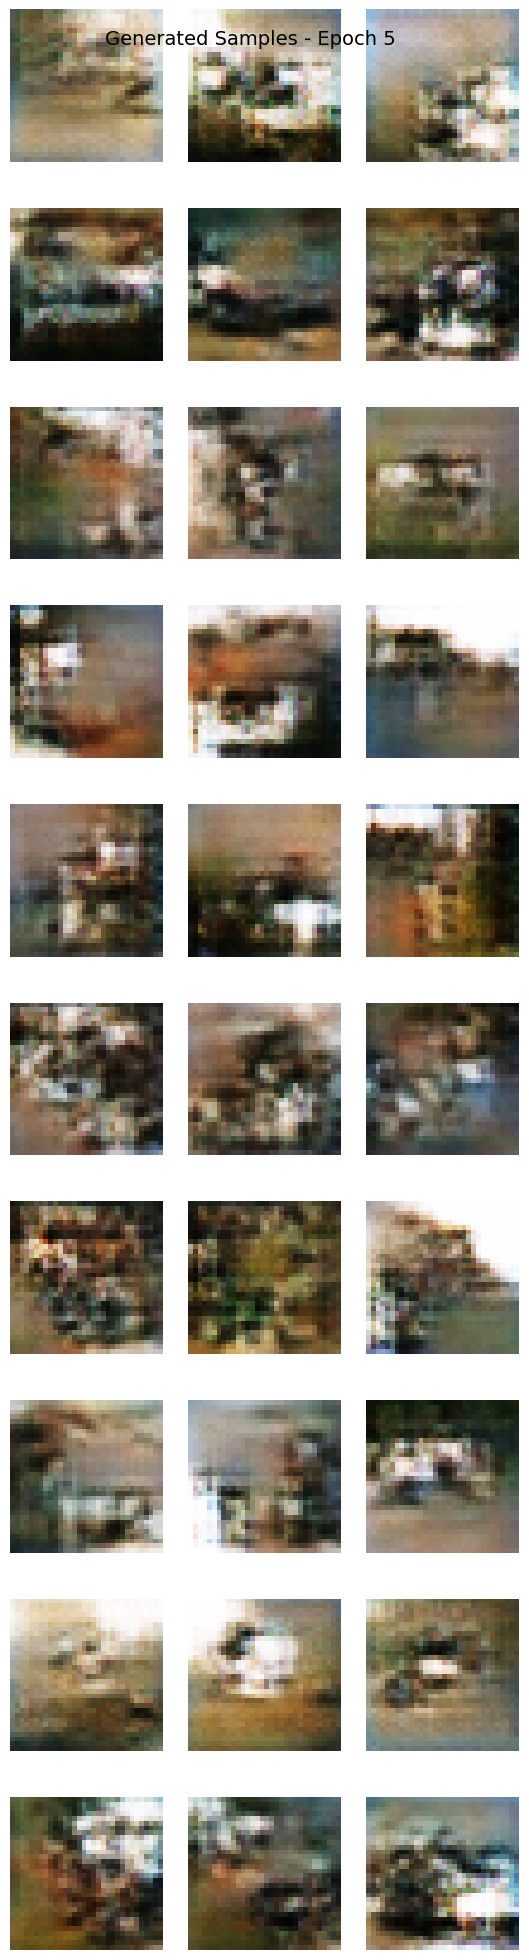

Epoch 6/50: 100%|████████████████████████████████████| 3125/3125 [01:21<00:00, 38.49it/s, D_loss=0.5967, G_loss=0.9697]



Epoch 6/50:
  Generator Loss: 0.9596
  Discriminator Loss: 0.6215
  Time: 81.19 seconds



Epoch 7/50: 100%|████████████████████████████████████| 3125/3125 [01:21<00:00, 38.46it/s, D_loss=0.5736, G_loss=1.1429]



Epoch 7/50:
  Generator Loss: 0.9413
  Discriminator Loss: 0.6244
  Time: 81.25 seconds



Epoch 8/50: 100%|████████████████████████████████████| 3125/3125 [01:22<00:00, 38.07it/s, D_loss=0.6630, G_loss=0.6426]



Epoch 8/50:
  Generator Loss: 0.9026
  Discriminator Loss: 0.6348
  Time: 82.08 seconds



Epoch 9/50: 100%|████████████████████████████████████| 3125/3125 [01:23<00:00, 37.46it/s, D_loss=0.5741, G_loss=1.0376]



Epoch 9/50:
  Generator Loss: 0.8807
  Discriminator Loss: 0.6368
  Time: 83.42 seconds



Epoch 10/50: 100%|███████████████████████████████████| 3125/3125 [01:28<00:00, 35.41it/s, D_loss=0.7478, G_loss=0.8685]



Epoch 10/50:
  Generator Loss: 0.8842
  Discriminator Loss: 0.6382
  Time: 88.26 seconds



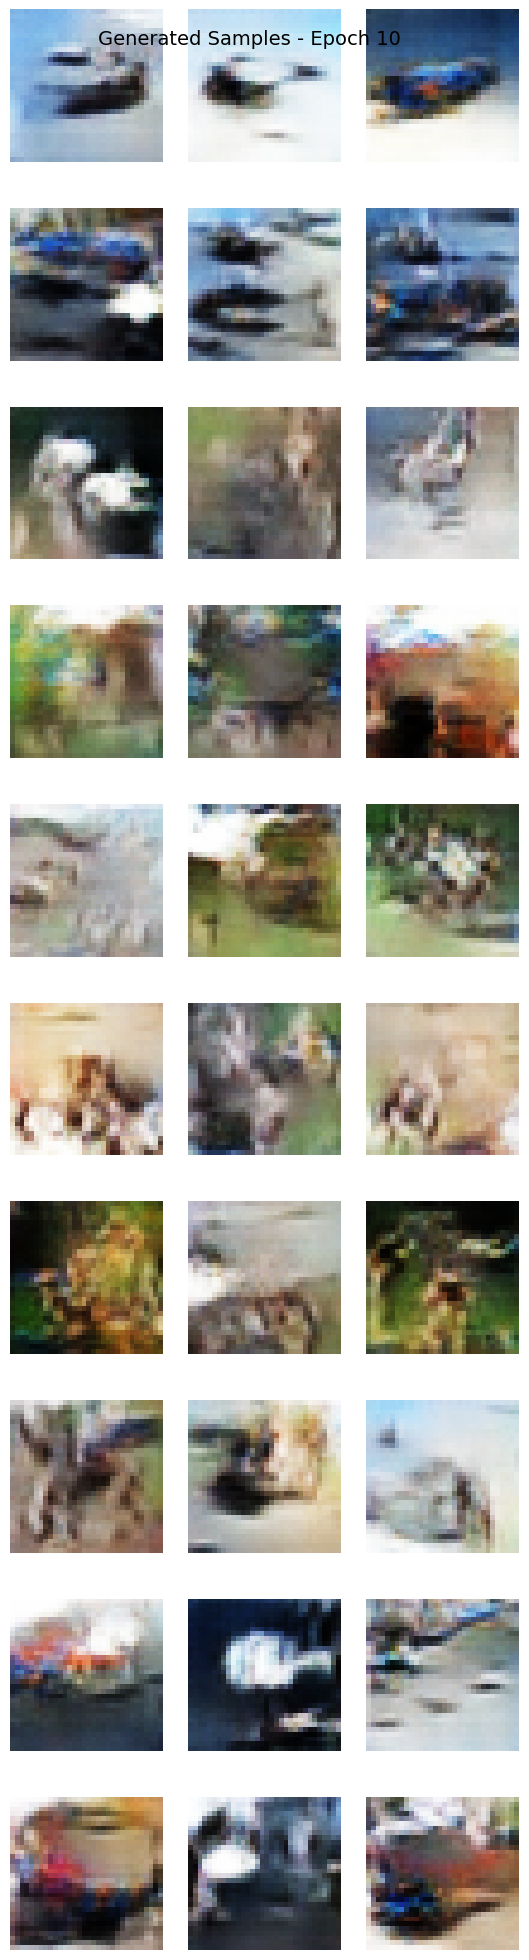


Evaluating GAN Performance...
Computing Inception Score...
Inception Score: 3.0802 ± 0.1895
Computing FID Score...
FID Score: 99.3447
Mode Coverage: 100.00%
Label Distribution: [ 88 112 117 103  97  93  99 102  99  82]



Epoch 11/50: 100%|███████████████████████████████████| 3125/3125 [01:26<00:00, 36.22it/s, D_loss=0.6446, G_loss=0.9346]



Epoch 11/50:
  Generator Loss: 0.8833
  Discriminator Loss: 0.6399
  Time: 86.27 seconds



Epoch 12/50: 100%|███████████████████████████████████| 3125/3125 [01:28<00:00, 35.34it/s, D_loss=0.5432, G_loss=0.7512]



Epoch 12/50:
  Generator Loss: 0.8960
  Discriminator Loss: 0.6383
  Time: 88.44 seconds



...


Epoch 13/50:
  Generator Loss: 0.9065
  Discriminator Loss: 0.6353
  Time: 88.83 seconds



Epoch 14/50: 100%|███████████████████████████████████| 3125/3125 [01:31<00:00, 34.10it/s, D_loss=0.6706, G_loss=0.9354]



Epoch 14/50:
  Generator Loss: 0.9055
  Discriminator Loss: 0.6337
  Time: 91.66 seconds



Epoch 15/50: 100%|███████████████████████████████████| 3125/3125 [01:31<00:00, 34.07it/s, D_loss=0.5859, G_loss=1.0049]



Epoch 15/50:
  Generator Loss: 0.9176
  Discriminator Loss: 0.6333
  Time: 91.71 seconds



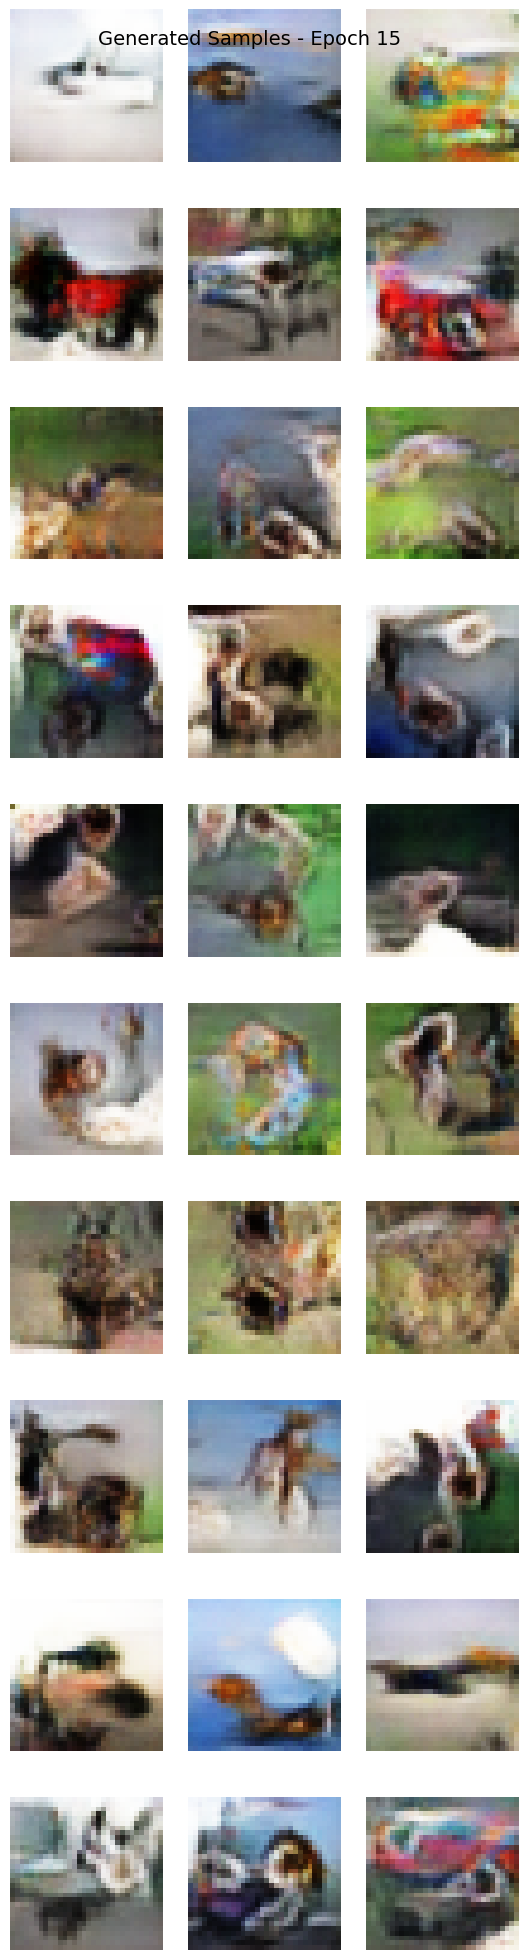

Epoch 16/50: 100%|███████████████████████████████████| 3125/3125 [01:29<00:00, 34.76it/s, D_loss=0.6062, G_loss=0.9484]



Epoch 16/50:
  Generator Loss: 0.9079
  Discriminator Loss: 0.6349
  Time: 89.91 seconds



Epoch 17/50: 100%|███████████████████████████████████| 3125/3125 [01:31<00:00, 34.15it/s, D_loss=0.6644, G_loss=0.8923]



Epoch 17/50:
  Generator Loss: 0.9046
  Discriminator Loss: 0.6364
  Time: 91.52 seconds



Epoch 18/50: 100%|███████████████████████████████████| 3125/3125 [01:30<00:00, 34.59it/s, D_loss=0.6314, G_loss=0.9486]



Epoch 18/50:
  Generator Loss: 0.9018
  Discriminator Loss: 0.6374
  Time: 90.35 seconds



Epoch 19/50: 100%|███████████████████████████████████| 3125/3125 [01:32<00:00, 33.89it/s, D_loss=0.7050, G_loss=0.7847]



Epoch 19/50:
  Generator Loss: 0.8979
  Discriminator Loss: 0.6387
  Time: 92.21 seconds



Epoch 20/50:  72%|█████████████████████████▎         | 2264/3125 [01:09<00:23, 36.77it/s, D_loss=0.5382, G_loss=1.0485]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000027061BC5BD0>
Traceback (most recent call last):
  File "D:\DeepLearning\Anaconda\envs\torch3\lib\site-packages\torch\utils\data\dataloader.py", line 1479, in __del__
  File "D:\DeepLearning\Anaconda\envs\torch3\lib\site-packages\torch\utils\data\dataloader.py", line 1443, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "D:\DeepLearning\Anaconda\envs\torch3\lib\multiprocessing\process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "D:\DeepLearning\Anaconda\envs\torch3\lib\multiprocessing\popen_spawn_win32.py", line 108, in wait
    res = _winapi.WaitForSingleObject(int(self._handle), msecs)
KeyboardInterrupt: 
Epoch 20/50:  73%|█████████████████████████▍         | 2267/3125 [01:10<00:26, 32.02it/s, D_loss=0.5382, G_loss=1.0485]

KeyboardInt

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time
from tqdm import tqdm
from scipy.linalg import sqrtm
from torchvision.models import inception_v3
import torch.nn.functional as F

# -----------------------------
# 1. 超参数
# -----------------------------
batch_size = 16
epoch_count = 50
noise_dim = 100
n_class = 10
img_size = 32
lr = 0.0002
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tags = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 
        'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# -----------------------------
# 2. 数据加载 (CIFAR-10)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root="./data", 
    train=True, 
    transform=transform, 
    download=False
)
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=2,
    drop_last=True  # 确保batch_size一致
)

test_dataset = datasets.CIFAR10(
    root="./data", 
    train=False, 
    transform=transform, 
    download=False
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

# 可视化样本
def show_sample_images():
    plt.figure(figsize=(10, 10))
    for i in range(25):
        idx = np.random.randint(0, len(train_dataset))
        img, label = train_dataset[idx]
        plt.subplot(5, 5, i + 1)
        # 反归一化
        img = img * 0.5 + 0.5
        plt.imshow(img.permute(1, 2, 0).numpy())
        plt.title(tags[label])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# show_sample_images()  # 取消注释以显示样本

# -----------------------------
# 3. 生成器模型
# -----------------------------
class Generator(nn.Module):
    def __init__(self, noise_dim, n_class, img_size=32):
        super(Generator, self).__init__()
        
        # 标签嵌入
        self.label_emb = nn.Embedding(n_class, 50)
        self.label_dense = nn.Linear(50, 8 * 8)
        
        # 噪声处理
        self.noise_dense = nn.Sequential(
            nn.Linear(noise_dim, 128 * 8 * 8),
            nn.LeakyReLU(0.2)
        )
        
        # 转置卷积层
        self.conv_blocks = nn.Sequential(
            # 输入: (129, 8, 8)
            nn.ConvTranspose2d(129, 128, 4, stride=2, padding=1),  # -> (128, 16, 16)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            
            nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1),  # -> (128, 32, 32)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(128, 3, 7, stride=1, padding=3),  # -> (3, 32, 32)
            nn.Tanh()
        )
    
    def forward(self, noise, labels):
        # 处理标签
        label_emb = self.label_emb(labels)  # (batch, 50)
        label_output = self.label_dense(label_emb)  # (batch, 64)
        label_output = label_output.view(-1, 1, 8, 8)  # (batch, 1, 8, 8)
        
        # 处理噪声
        noise_output = self.noise_dense(noise)  # (batch, 128*8*8)
        noise_output = noise_output.view(-1, 128, 8, 8)  # (batch, 128, 8, 8)
        
        # 合并
        gen_input = torch.cat([noise_output, label_output], dim=1)  # (batch, 129, 8, 8)
        
        # 生成图像
        img = self.conv_blocks(gen_input)
        return img

# -----------------------------
# 4. 判别器模型
# -----------------------------
class Discriminator(nn.Module):
    def __init__(self, n_class, img_size=32):
        super(Discriminator, self).__init__()
        
        # 标签嵌入
        self.label_emb = nn.Embedding(n_class, 50)
        self.label_dense = nn.Linear(50, img_size * img_size)
        
        # 卷积层
        self.conv_blocks = nn.Sequential(
            # 输入: (4, 32, 32) - 3通道图像 + 1通道标签
            nn.Conv2d(4, 128, 3, stride=2, padding=1),  # -> (128, 16, 16)
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(128, 128, 3, stride=2, padding=1),  # -> (128, 8, 8)
            nn.LeakyReLU(0.2),
            
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128 * 8 * 8, 1),
            nn.Sigmoid()
        )
    
    def forward(self, img, labels):
        # 处理标签
        label_emb = self.label_emb(labels)  # (batch, 50)
        label_output = self.label_dense(label_emb)  # (batch, 32*32)
        label_output = label_output.view(-1, 1, img_size, img_size)  # (batch, 1, 32, 32)
        
        # 合并图像和标签
        d_input = torch.cat([img, label_output], dim=1)  # (batch, 4, 32, 32)
        
        # 判别
        validity = self.conv_blocks(d_input)
        return validity

# -----------------------------
# 5. 初始化模型
# -----------------------------
G = Generator(noise_dim, n_class, img_size).to(device)
D = Discriminator(n_class, img_size).to(device)

print("Generator:")
print(G)
print("\nDiscriminator:")
print(D)

# 损失函数
criterion = nn.BCELoss()

# 优化器
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# -----------------------------
# 6. Inception Score 计算
# -----------------------------
def load_inception_model():
    """加载预训练的Inception v3模型"""
    inception_model = inception_v3(pretrained=True, transform_input=False)
    inception_model.fc = nn.Identity()  # 移除最后的分类层
    inception_model.eval()
    inception_model = inception_model.to(device)
    return inception_model

def get_inception_features(imgs, inception_model):
    """提取Inception特征"""
    # 调整图像大小到299x299 (Inception v3的输入尺寸)
    if imgs.size(-1) != 299:
        imgs = F.interpolate(imgs, size=(299, 299), mode='bilinear', align_corners=False)
    
    with torch.no_grad():
        features = inception_model(imgs)
    return features

def calculate_inception_score(imgs, inception_model, n_split=10, eps=1e-16):
    """
    计算Inception Score
    """
    N = imgs.size(0)
    
    # 加载完整的Inception模型用于分类
    inception_full = inception_v3(pretrained=True, transform_input=False).to(device)
    inception_full.eval()
    
    # 调整图像大小
    if imgs.size(-1) != 299:
        imgs = F.interpolate(imgs, size=(299, 299), mode='bilinear', align_corners=False)
    
    # 获取预测概率
    with torch.no_grad():
        preds = F.softmax(inception_full(imgs), dim=1).cpu().numpy()
    
    # 分割计算
    split_scores = []
    for k in range(n_split):
        part = preds[k * (N // n_split): (k + 1) * (N // n_split), :]
        py = np.mean(part, axis=0)
        scores = []
        for i in range(part.shape[0]):
            pyx = part[i, :]
            scores.append(np.sum(pyx * np.log(pyx / (py + eps) + eps)))
        split_scores.append(np.exp(np.mean(scores)))
    
    return np.mean(split_scores), np.std(split_scores)

# -----------------------------
# 7. FID Score 计算
# -----------------------------
def calculate_fid(real_features, fake_features):
    """
    计算Fréchet Inception Distance
    """
    # 转换为numpy
    if torch.is_tensor(real_features):
        real_features = real_features.cpu().numpy()
    if torch.is_tensor(fake_features):
        fake_features = fake_features.cpu().numpy()
    
    # 计算均值和协方差
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    
    # 计算FID
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

# -----------------------------
# 8. 综合评估函数
# -----------------------------
def evaluate_gan(G, inception_model, test_loader, num_samples=1000):
    """
    综合评估GAN性能
    """
    print("\n" + "="*60)
    print("Evaluating GAN Performance...")
    print("="*60)
    
    G.eval()
    
    # 1. 生成样本
    gen_imgs_list = []
    gen_labels_list = []
    
    with torch.no_grad():
        for _ in range(num_samples // batch_size):
            noise = torch.randn(batch_size, noise_dim, device=device)
            labels = torch.randint(0, n_class, (batch_size,), device=device)
            gen_imgs = G(noise, labels)
            gen_imgs_list.append(gen_imgs)
            gen_labels_list.append(labels)
    
    gen_imgs = torch.cat(gen_imgs_list, dim=0)[:num_samples]
    gen_labels = torch.cat(gen_labels_list, dim=0)[:num_samples]
    
    # 2. 计算Inception Score
    print("Computing Inception Score...")
    is_mean, is_std = calculate_inception_score(gen_imgs, inception_model)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 3. 计算FID Score
    print("Computing FID Score...")
    
    # 提取生成图像特征
    fake_features_list = []
    with torch.no_grad():
        for i in range(0, len(gen_imgs), batch_size):
            batch = gen_imgs[i:i+batch_size]
            features = get_inception_features(batch, inception_model)
            fake_features_list.append(features)
    fake_features = torch.cat(fake_features_list, dim=0).cpu().numpy()
    
    # 提取真实图像特征
    real_features_list = []
    n_batches = num_samples // batch_size
    for i, (imgs, _) in enumerate(test_loader):
        if i >= n_batches:
            break
        imgs = imgs.to(device)
        with torch.no_grad():
            features = get_inception_features(imgs, inception_model)
        real_features_list.append(features)
    real_features = torch.cat(real_features_list, dim=0).cpu().numpy()[:num_samples]
    
    fid_score = calculate_fid(real_features, fake_features)
    print(f"FID Score: {fid_score:.4f}")
    
    # 4. 模式覆盖率
    unique_labels = len(torch.unique(gen_labels))
    mode_coverage = unique_labels / n_class * 100
    print(f"Mode Coverage: {mode_coverage:.2f}%")
    
    # 5. 类别分布
    label_counts = torch.bincount(gen_labels, minlength=n_class)
    print(f"Label Distribution: {label_counts.cpu().numpy()}")
    
    print("="*60 + "\n")
    
    return {
        'is_mean': is_mean,
        'is_std': is_std,
        'fid': fid_score,
        'mode_coverage': mode_coverage
    }

# -----------------------------
# 9. 可视化函数
# -----------------------------
def show_samples(num_samples, n_class, g_model, epoch=0):
    """显示每个类别生成的样本"""
    g_model.eval()
    
    fig, axes = plt.subplots(n_class, num_samples, figsize=(num_samples*2, n_class*2))
    fig.tight_layout()
    fig.subplots_adjust(wspace=0.1, hspace=0.3)
    
    with torch.no_grad():
        for label in range(n_class):
            noise = torch.randn(num_samples, noise_dim, device=device)
            labels = torch.full((num_samples,), label, dtype=torch.long, device=device)
            gen_imgs = g_model(noise, labels)
            
            # 反归一化
            gen_imgs = gen_imgs * 0.5 + 0.5
            gen_imgs = gen_imgs.cpu()
            
            for j in range(num_samples):
                img = gen_imgs[j].permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)
                
                if num_samples == 1:
                    ax = axes[label]
                else:
                    ax = axes[label, j]
                
                ax.imshow(img)
                ax.axis('off')
                
                if j == 0:
                    ax.set_ylabel(tags[label], fontsize=10)
    
    plt.suptitle(f'Generated Samples - Epoch {epoch}', fontsize=14)
    plt.savefig(f'generated_samples_epoch_{epoch}.png', dpi=150, bbox_inches='tight')
    plt.show()

# -----------------------------
# 10. 训练函数
# -----------------------------
def train_step(real_images, real_labels):
    """单步训练"""
    current_batch_size = real_images.size(0)
    
    # 标签
    real_label = torch.ones(current_batch_size, 1, device=device)
    fake_label = torch.zeros(current_batch_size, 1, device=device)
    
    # ---------------------
    # 训练判别器
    # ---------------------
    optimizer_D.zero_grad()
    
    # 真实图像
    real_validity = D(real_images, real_labels)
    d_real_loss = criterion(real_validity, real_label)
    
    # 生成图像
    noise = torch.randn(current_batch_size, noise_dim, device=device)
    fake_images = G(noise, real_labels)
    fake_validity = D(fake_images.detach(), real_labels)
    d_fake_loss = criterion(fake_validity, fake_label)
    
    # 总判别器损失
    d_loss = (d_real_loss + d_fake_loss) / 2
    d_loss.backward()
    optimizer_D.step()
    
    # ---------------------
    # 训练生成器
    # ---------------------
    optimizer_G.zero_grad()
    
    noise = torch.randn(current_batch_size, noise_dim, device=device)
    fake_images = G(noise, real_labels)
    validity = D(fake_images, real_labels)
    g_loss = criterion(validity, real_label)
    
    g_loss.backward()
    optimizer_G.step()
    
    return d_loss.item(), g_loss.item()

def train(train_loader, epochs=epoch_count):
    """训练主循环"""
    
    # 加载Inception模型用于评估
    print("Loading Inception model for evaluation...")
    inception_model = load_inception_model()
    
    history = {
        'd_loss': [],
        'g_loss': [],
        'metrics': []
    }
    
    for epoch in range(epochs):
        G.train()
        D.train()
        
        d_loss_list = []
        g_loss_list = []
        start = time.time()
        
        # 训练循环
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for real_images, real_labels in pbar:
            real_images = real_images.to(device)
            real_labels = real_labels.to(device)
            
            d_loss, g_loss = train_step(real_images, real_labels)
            
            d_loss_list.append(d_loss)
            g_loss_list.append(g_loss)
            
            pbar.set_postfix({
                'D_loss': f'{d_loss:.4f}',
                'G_loss': f'{g_loss:.4f}'
            })
        
        # 记录平均损失
        avg_d_loss = np.mean(d_loss_list)
        avg_g_loss = np.mean(g_loss_list)
        history['d_loss'].append(avg_d_loss)
        history['g_loss'].append(avg_g_loss)
        
        elapsed = time.time() - start
        print(f'\nEpoch {epoch+1}/{epochs}:')
        print(f'  Generator Loss: {avg_g_loss:.4f}')
        print(f'  Discriminator Loss: {avg_d_loss:.4f}')
        print(f'  Time: {elapsed:.2f} seconds\n')
        
        # 显示生成样本
        if (epoch + 1) % 5 == 0:
            show_samples(3, n_class, G, epoch+1)
        
        # 每10个epoch评估一次
        if (epoch + 1) % 10 == 0:
            metrics = evaluate_gan(G, inception_model, test_loader, num_samples=1000)
            history['metrics'].append(metrics)
            
            # 保存检查点
            torch.save({
                'epoch': epoch,
                'generator_state_dict': G.state_dict(),
                'discriminator_state_dict': D.state_dict(),
                'optimizer_G_state_dict': optimizer_G.state_dict(),
                'optimizer_D_state_dict': optimizer_D.state_dict(),
                'metrics': metrics
            }, f'checkpoint_epoch_{epoch+1}.pt')
    
    # 最终评估
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)
    final_metrics = evaluate_gan(G, inception_model, test_loader, num_samples=2000)
    
    # 绘制训练曲线
    plot_training_history(history)
    
    return history

def plot_training_history(history):
    """绘制训练历史"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 损失曲线
    axes[0].plot(history['d_loss'], label='Discriminator Loss', alpha=0.7)
    axes[0].plot(history['g_loss'], label='Generator Loss', alpha=0.7)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss Curves')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 评估指标曲线
    if len(history['metrics']) > 0:
        epochs_evaluated = [(i+1)*10 for i in range(len(history['metrics']))]
        is_scores = [m['is_mean'] for m in history['metrics']]
        fid_scores = [m['fid'] for m in history['metrics']]
        
        ax1 = axes[1]
        ax2 = ax1.twinx()
        
        ax1.plot(epochs_evaluated, is_scores, 'b-o', label='IS', alpha=0.7)
        ax2.plot(epochs_evaluated, fid_scores, 'r-s', label='FID', alpha=0.7)
        
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Inception Score', color='b')
        ax2.set_ylabel('FID Score', color='r')
        ax1.set_title('Quality Metrics Over Training')
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='upper left')
        ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

# -----------------------------
# 11. 开始训练
# -----------------------------
print(f"Using device: {device}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of batches per epoch: {len(train_loader)}\n")

# 开始训练
history = train(train_loader, epochs=epoch_count)

print("\n Training completed!")
print("Final results and visualizations have been saved.")